In [1]:
def set_mpl_params(dpi=150, figsize=(9, 6), grid=True, font_size=16, font_family='serif'):
    """Configure matplotlib parameters for consistent plot styling.
    
    Args:
        dpi (int): Output resolution
        figsize (tuple): Figure dimensions (width, height) in inches
        grid (bool): Toggle grid display
        font_size (int): Base font size
        font_family (str): Font family for text elements
    """
    import matplotlib as mpl
    mpl.rcParams.update({
        'figure.dpi': dpi,
        'figure.figsize': figsize,
        'font.size': font_size,
        'font.family': font_family
    })

set_mpl_params()

## Preamble

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

## Question 1

Using the iris dataset, implement a classifier using Nearest Centroid Classification Rule. Visualize the results.

Tasks

1. Exploratory Analysis (Optional here, but usually a good practice)
2. Load the iris dataset and use any two features.
3. Split the data for training and testing (e.g. 4:1)
4. Compute class centroids (mean of features for each class).
5. Using an appropriate distance metric (e.g. Euclidean distance), develop a nearest centroid classifier.
6. Classify test samples by assigning them to the class of the nearest centroid.
7. Visualize your results.
8. Calculate an accuracy score for the classifier on the test set. test set.


In [3]:
class NearestCentroid:
    """Nearest Centroid Classifier using Euclidean distance"""
    
    def fit(self, X, y):
        """Calculate class centroids from training data.
        
        Args:
            X (ndarray): Training features (n_samples, n_features)
            y (ndarray): Target values (n_samples,)
        """
        self.centroids = []
        for c in np.unique(y):
            self.centroids.append(np.mean(X[y == c], axis=0))
    
    def predict(self, X):
        """Predict class labels for input data.
        
        Args:
            X (ndarray): Input features (n_samples, n_features)
            
        Returns:
            ndarray: Predicted class labels (n_samples,)
        """
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

In [4]:
def plot_results(clf, X_train, y_train, X_test, y_test, title):
    """Visualize decision boundaries and classification results.
    
    Args:
        clf: Trained classifier object with predict method
        X_train (ndarray): Training features
        y_train (ndarray): Training labels
        X_test (ndarray): Test features
        y_test (ndarray): True test labels
        title (str): Plot title
    """
    cmap = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    h = 0.02  # Step size in mesh
    
    # Create decision boundary mesh
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Get predictions for mesh grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Get test predictions and misclassifications
    y_pred = clf.predict(X_test)
    misclassified = y_pred != y_test
    
    plt.figure()
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    
    # Plot training data
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                edgecolor='k', s=50, label='Training Data')
    
    # Plot centroids for Nearest Centroid
    if hasattr(clf, 'centroids'):
        centroids = np.array(clf.centroids)
        plt.scatter(centroids[:, 0], centroids[:, 1],
                    marker='X', s=200, linewidths=3,
                    color='black', label='Centroids')
    
    # Plot test data with different markers
    plt.scatter(X_test[~misclassified, 0], X_test[~misclassified, 1],
                c=y_test[~misclassified], marker='s', s=80,
                edgecolor='k', label='Correct Predictions')
    
    # Highlight misclassifications
    if misclassified.any():
        plt.scatter(X_test[misclassified, 0], X_test[misclassified, 1],
                    marker='X', s=100, linewidths=2,
                    color='red', edgecolor='k', label='Misclassified')
    
    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Sepal Width (cm)')
    plt.title(title)
    plt.legend()

In [5]:
# Load and prepare data
iris = load_iris()
X = iris.data[:, :2]  # Use first two features for visualization
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

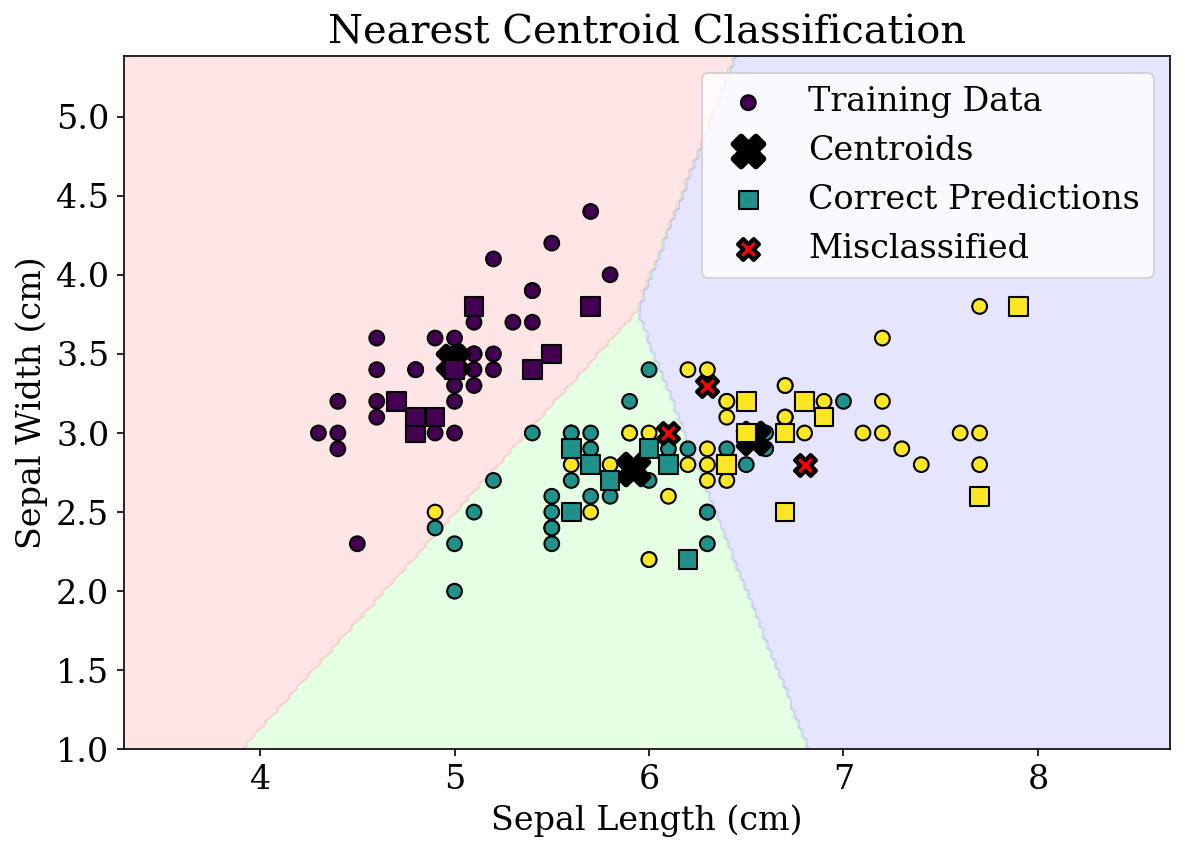

In [6]:
# Train and visualize Nearest Centroid
nc = NearestCentroid()
nc.fit(X_train, y_train)
plot_results(nc, X_train, y_train, X_test, y_test, 
            "Nearest Centroid Classification")
plt.show()

## Question 2

Using the iris dataset, implement a classifier using **Nearest Neighbor Classification Rule**. Visualize the results.

Tasks

1. Exploratory Analysis (Optional here, but usually a good practice)
2. Load the iris dataset and use any two features.
3. Split the data for training and testing (e.g. 4:1)
4. Using an appropriate distance metric (e.g. Euclidean distance), develop a nearest neighbor classifier.
5. Classify test samples by assigning them to the class of the nearest neighbor.
6. Visualize your results.
7. Calculate an accuracy score for the classifier on the test set and compare it with above.

In [7]:
class NearestNeighbor:
    """k-Nearest Neighbor Classifier (k=1)"""
    
    def fit(self, X, y):
        """Store training data.
        
        Args:
            X (ndarray): Training features (n_samples, n_features)
            y (ndarray): Target values (n_samples,)
        """
        self.X_train = X
        self.y_train = y
    
    def predict(self, X):
        """Predict class labels using nearest neighbor.
        
        Args:
            X (ndarray): Input features (n_samples, n_features)
            
        Returns:
            ndarray: Predicted class labels (n_samples,)
        """
        distances = np.sqrt(((self.X_train[:, np.newaxis] - X)**2).sum(axis=2))
        return self.y_train[np.argmin(distances, axis=0)]

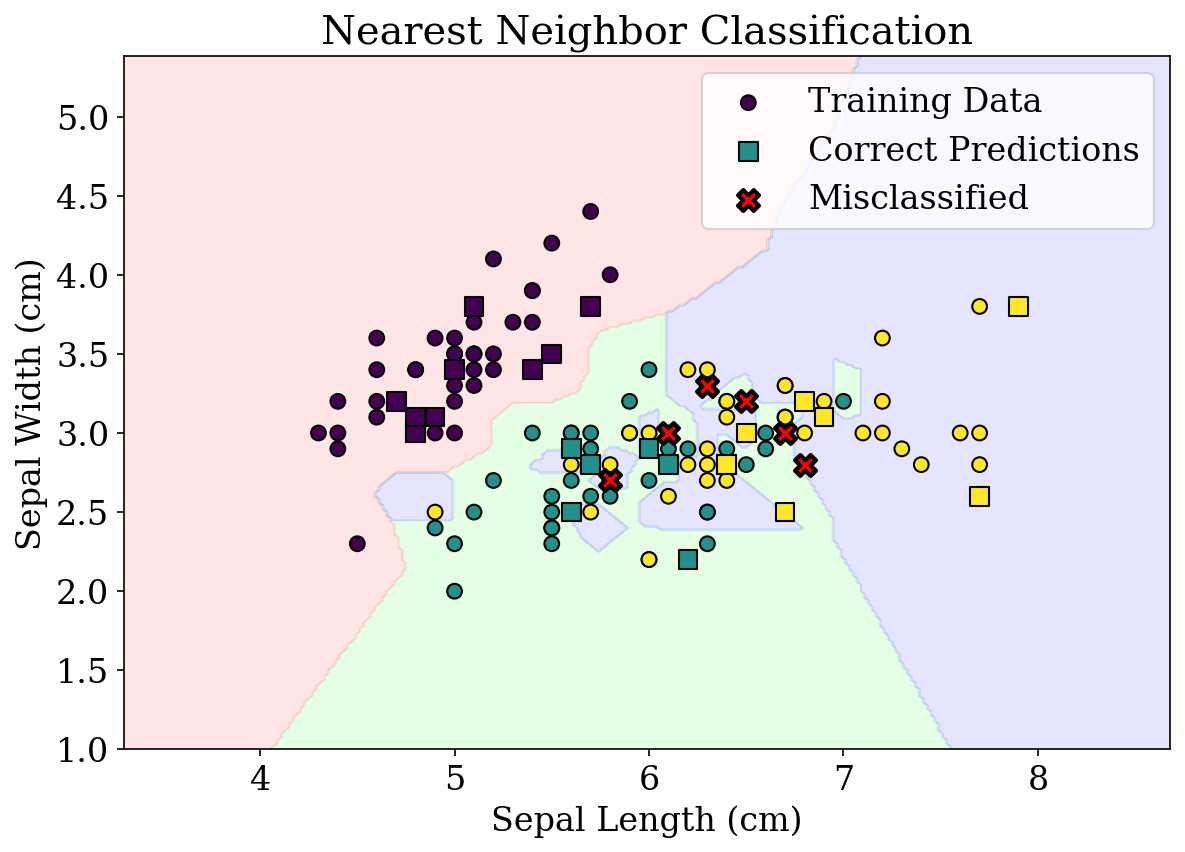

In [8]:
# Train and visualize Nearest Neighbor
nn = NearestNeighbor()
nn.fit(X_train, y_train)
plot_results(nn, X_train, y_train, X_test, y_test,
            "Nearest Neighbor Classification")
plt.show()

In [9]:
# Calculate accuracies
print(f"Nearest Centroid Test Accuracy: {np.mean(nc.predict(X_test) == y_test):.2%}")
print(f"Nearest Neighbor Test Accuracy: {np.mean(nn.predict(X_test) == y_test):.2%}")

Nearest Centroid Test Accuracy: 90.00%
Nearest Neighbor Test Accuracy: 80.00%


## Question 3

A medical screening test categorizes patients into 5 risk groups (1-5) based on certain parameters. You have a training dataset of 20 patients where each patient belongs to one of these risk groups and has been diagnosed as either healthy (0) or sick (1). Implement the **Discrete Histogram Classification Rule** to predict the diagnosis of new patients.

Training data is provided as follows:

	Risk Group 1: 3 healthy, 1 sick
	Risk Group 2: 1 healthy, 4 sick
	Risk Group 3: 2 healthy, 3 sick
	Risk Group 4: 4 healthy, 1 sick
	Risk Group 5: 1 healthy, 0 sick

In [10]:
def create_training_data():
    # Create sample data structure
    risk_groups = np.array([1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5])
    diagnoses = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0])
    return risk_groups, diagnoses

In [11]:
def discrete_histogram_classifier(X_train, y_train, x_test):
    # Number of unique categories
    categories = np.unique(X_train)
    
    predictions = []
    
    for x in x_test:
        # Count occurrences of class 0 and 1 for current category
        mask = X_train == x
        U = np.sum((y_train == 0) & mask)  # count of class 0
        V = np.sum((y_train == 1) & mask)  # count of class 1
        
        # Apply the classification rule
        prediction = 1 if U < V else 0
        predictions.append(prediction)
    
    return np.array(predictions)

In [12]:
# Create and test the classifier
X_train, y_train = create_training_data()

# Test cases
test_cases = np.array([1, 2, 3, 4, 5])
predictions = discrete_histogram_classifier(X_train, y_train, test_cases)

# Print results
for risk_group, pred in zip(test_cases, predictions):
    print(f"Risk Group {risk_group}: Predicted Diagnosis = {pred}")


Risk Group 1: Predicted Diagnosis = 0
Risk Group 2: Predicted Diagnosis = 1
Risk Group 3: Predicted Diagnosis = 1
Risk Group 4: Predicted Diagnosis = 0
Risk Group 5: Predicted Diagnosis = 0
